Part 1 - Renting Cars

The problem statement of part 1 is to implement the Jack's Car Rental Problem as described in 
Sutton and Barto on page 81 (Example 4.2)

For this part, you should train a RL agent to solve this problem using POLICY ITERATION and display the policy as a heatmap

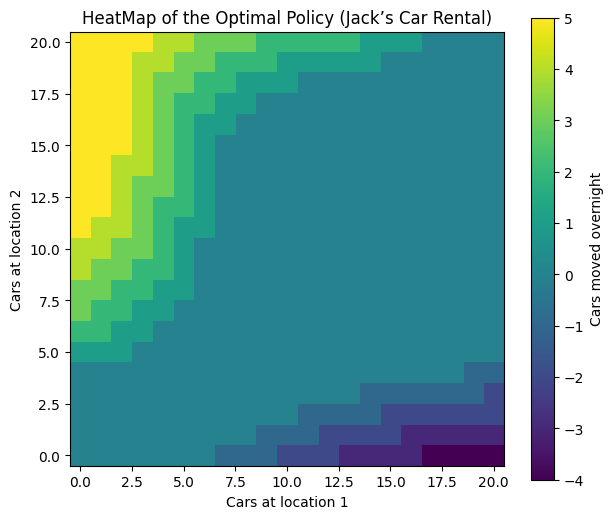

In [29]:
import numpy as np
import math
import matplotlib.pyplot as plt

# constants
M=20; A=5; G=0.9
RA, RB, TA, TB = 3,4,3,2

P = {}
def pois(n,l):
    if (n,l) not in P:
        P[(n,l)] = math.exp(-l)*l**n/math.factorial(n)
    return P[(n,l)]

PR = np.zeros((11,11))
PT = np.zeros((11,11))
for i in range(11):
    for j in range(11):
        PR[i,j] = pois(i,RA)*pois(j,RB)
        PT[i,j] = pois(i,TA)*pois(j,TB)

V = np.zeros((21,21))
Policy = np.zeros((21,21),dtype=int)

# initial policy: move 1 car from location with higher cars to locaton with lower cars
for i in range(21):
    for j in range(21):
        if i>j:
          Policy[i,j] = 1
        elif i<j:
          Policy[i,j]=-1
        else:
          Policy[i,j]=0



def ER(i,j,a):
    x = min(M,i-a); y = min(M,j+a)
    v = -2*abs(a)
    for r1 in range(11):
        for r2 in range(11):
            p = PR[r1,r2]
            u = min(x,r1)
            w = min(y,r2)
            rew = 10*(u+w)
            xa = x-u
            yb = y-w
            for t1 in range(11):
                for t2 in range(11):
                    v += p*PT[t1,t2]*(rew + G*V[min(M,xa+t1),min(M,yb+t2)])
    return v

Optimum = 0
while not Optimum:
    # policy evaluation
    while 1:
        d = 0
        for i in range(21):
            for j in range(21):
                o = V[i,j]
                V[i,j] = ER(i,j,Policy[i,j])
                d = max(d,abs(o-V[i,j]))
        if d < 1e-2:
            break

    # policy improvement
    Optimum = 1
    for i in range(21):
        for j in range(21):
            b = Policy[i,j]
            m = -1e9
            for a in range(-A,A+1):
                if a<=i and -a<=j:
                    q = ER(i,j,a)
                    if q>m:
                        m=q
                        Policy[i,j]=a
            if b!=Policy[i,j]: 
                Optimum=0

plt.figure(figsize=(7, 6))
plt.imshow(Policy, origin='lower', cmap='viridis')
plt.colorbar(label='Cars moved overnight')
plt.xlabel('Cars at location 1')
plt.ylabel('Cars at location 2')
plt.title('HeatMap of the Optimal Policy (Jack’s Car Rental)')
plt.show()



Part 2 - Gambling Time

The problem statement of part 2 is to implement the Gambler's Problem as described in Sutton and Barto on page 84 (Example 4.3)

For this part, you should train the RL agent to solve this problem using VALUE ITERATION and display the policy as a bar graph

In [30]:
import numpy as np
import matplotlib.pyplot as plt
#initial value:to stake only 1 coin
p = 0.4         
goal = 100      
V = np.zeros(goal+1)  
V[goal] = 1          
policy = np.zeros(goal+1)  

# value iteration
theta = 1e-8
while True:
    delta = 0
    for s in range(1,goal):
        action_values = []
        for a in range(1, min(s, goal-s)+1):  
            val = p*V[s+a] + (1-p)*V[s-a]
            action_values.append(val)
        if action_values:
            v = max(action_values)
            delta = max(delta, abs(v-V[s]))
            V[s] = v
    if delta < theta: break


for s in range(1,goal):
    acts = range(1, min(s, goal-s)+1)
    if acts:
        q = [p*V[s+a] + (1-p)*V[s-a] for a in acts]
        policy[s] = acts[np.argmax(q)]


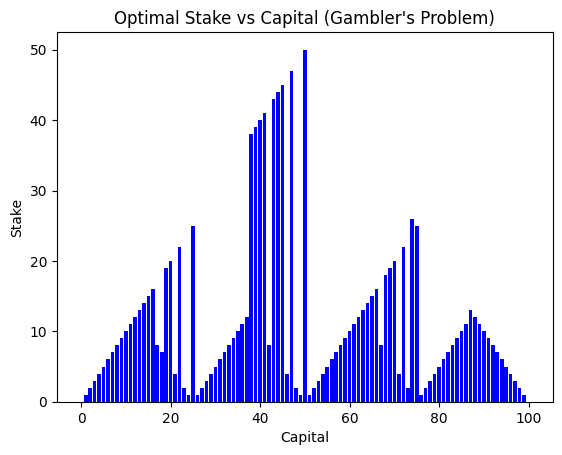

In [31]:
plt.bar(range(goal+1), policy, color='blue')
plt.xlabel("Capital")
plt.ylabel("Stake")
plt.title("Optimal Stake vs Capital (Gambler's Problem)")
plt.show()

Part 3 - Solving Lights out

Remember that MDP you made for Lights Out last week? Well let's use RL to solve it! You can use either Policy Iteration or Value Iteration. Just find the optimal policy.

Once you have the policy try to see if you can figure out using this policy what is the minimum number of moves required to guarantee that any initial possible board can be solved (i.e. if we play optimally we will need atleast this many moves to guarantee that you can find the goal state)

In [32]:
import numpy as np
N = 4
NUM_STATES = 2 ** (N * N)
NUM_ACTIONS = N * N
GAMMA = 0.9
THETA = 1e-6

def state_to_grid(state):
    bits = np.array(list(np.binary_repr(state, N * N)), dtype=int)
    return bits.reshape(N, N)

def grid_to_state(grid):
    return int("".join(grid.astype(str).flatten()), 2)

def toggle(grid, i, j):
    for x, y in [(i,j),(i-1,j),(i+1,j),(i,j-1),(i,j+1)]:
        if 0 <= x < N and 0 <= y < N:
            grid[x, y] ^= 1
    return grid

def transition(state, action):
    grid = state_to_grid(state)
    i, j = divmod(action, N)
    grid=toggle(grid, i, j)
    next_state = grid_to_state(grid)
    reward = 1 if next_state == 0 else 0
    return next_state, reward


T = np.zeros((NUM_STATES, NUM_ACTIONS), dtype=int)
R = np.zeros((NUM_STATES, NUM_ACTIONS), dtype=float)

for s in range(NUM_STATES):
    for a in range(NUM_ACTIONS):
        ns, r = transition(s, a)
        T[s, a] = ns
        R[s, a] = r

V = np.zeros(NUM_STATES, dtype=float)
policy = np.zeros(NUM_STATES, dtype=int)

iteration = 0
while True:
    delta = 0
    iteration += 1

    for s in range(1, NUM_STATES):
        q_values = R[s] + GAMMA * V[T[s]]
        new_v = np.max(q_values)
        delta = max(delta, abs(V[s] - new_v))
        V[s] = new_v

    if delta < THETA:
        break

for s in range(NUM_STATES):
    if s == 0:
        policy[s] = -1
    else:
        policy[s] = np.argmax(R[s] + GAMMA * V[T[s]])





